In [ ]:
%matplotlib inline
import mcstasscript as ms


def make_trex(L0=2.4, RRM=18, phase_P=-55, phase_M=-175, freq=14.0):
    trex = ms.McStas_instr(
        "TRex_choppers", author="Bing Li", output_path="trex_choppers"
    )
    trex.settings(suppress_output=True)

    # ------------------- instrument parameters -------------------
    L0 = trex.add_parameter(
        "L0",
        value=L0,
        comment="wavelength in [Å] used to calculate the minimum and maximum wavelength "
        + "for the source component by adding and subtracting a set wavelength",
    )

    RRM = trex.add_parameter(
        "int",
        "RRM",
        value=RRM,
        comment="repetition rate multiplication",
    )
    trex.add_parameter(
        "int",
        "phase_P",
        value=phase_P,
        comment="angular offset for the P-Chopper {0: 20 deg Opening, 55: 35 deg Opening}",
    )
    trex.add_parameter(
        "int",
        "phase_M",
        value=phase_M,
        comment="angular offset for the M-Chopper {0: 2.2 deg Opening, 175: 4.3 deg Opening}",
    )

    # ------------------- Declare -------------------
    trex.add_declare_var(
        "double",
        "T_offset",
        value=1.7e-3,
        comment="Time offset in [s] to shift to the center of long pulse",
    )
    trex.add_declare_var(
        "double",
        "f",
        value=freq,
        comment="Source frequency in [Hz]",
    )
    trex.add_declare_var(
        "double",
        "v0",
        comment="characteristic velocity in [m/s]",
    )

    # ------------------- More declare -------------------

    trex.append_declare("""

    // BW1 Chopper

    double position_BW1[3] = {0.011348994153930106, 0.0, 32.0};
    double rotation_BW1[3] = {0, 0.124542024141650, 0};
    double radius_BW1 = 0.35; // [m]
    double delta_y_BW1 = -0.3075; // [m]
    double nslits_BW1 = 1;
    char theta_pos_BW1[256] = "0";
    char theta_width_BW1[256] = "61.4";

    double tof_BW1; // [s]
    double f_BW1; // frequency [Hz]
    double delay_BW1; //time delay [s]


    // BW2 Chopper

    double position_BW2[3] = {0.03140505829452013, 0.0, 40.0};
    double rotation_BW2[3] = {0, 0.162739331227240, 0};
    double radius_BW2 = 0.35; // [m]
    double delta_y_BW2 = -0.3075; // [m]
    double nslits_BW2 = 1;
    char theta_pos_BW2[256] = "0";
    char theta_width_BW2[256] = "63.3";


    double tof_BW2; // [s]
    double f_BW2; // frequency [Hz]
    double delay_BW2; // time delay [s]

    // P1 Chopper

    double position_P1[3] = {0.4108460115539497, 0.0, 107.95};
    double rotation_P1[3] = {0, 0.430122381481144, 0};
    double radius_P1 = 0.35; // [m]
    double delta_y_P1 = 0.305; // [m]
    double nslits_P1 = 4;
    char theta_pos_P1[256] = "0;125;180;305"; 
    char theta_width_P1[256] = "20;35;20;35";


    double tof_P1; // [s]
    double f_P1; // frequency [Hz]
    double delay_P1; //time delay [s]
    double phase_P1; // angular delay [deg]

    // P2 Chopper

    double position_P2[3] = {0.41159673083080733, 0.0, 108.055};
    double rotation_P2[3] = {0, 0.430122381481144, 0};
    double radius_P2 = 0.35; // [m]
    double delta_y_P2 = 0.305; // [m]
    double nslits_P2 = 4;
    char theta_pos_P2[256] = "0;125;180;305"; 
    char theta_width_P2[256] = "20;35;20;35";

    double tof_P2; // [s]
    double f_P2; // frequency [Hz]
    double delay_P2; //time delay [s]
    double phase_P2; // angular delay [deg]



    // M1 Chopper

    double position_M1[3] = {0.8166097806955753, 0.0, 161.995};
    double rotation_M1[3] = {0, 0.430122381481144, 0};
    double radius_M1 = 0.35; // [m]
    double delta_y_M1 = 0.325; // [m]
    double nslits_M1 = 2;
    char theta_pos_M1[256] = "0;-175"; 
    char theta_width_M1[256] = "2.5;4.4";

    double tof_M1; // [s]
    double f_M1; // frequency [Hz]
    double delay_M1; //time delay [s]
    double phase_M1; // angular delay [deg]


    // M2 Chopper

    double position_M2[3] = {0.8166097806955753, 0.0, 162.005};
    double rotation_M2[3] = {0, 0.430122381481144, 0};
    double radius_M2 = 0.35; // [m]
    double delta_y_M2 = -0.325; // [m]
    double nslits_M2 = 2;
    char theta_pos_M2[256] = "0;-175"; 
    char theta_width_M2[256] = "2.5;4.4";

    double tof_M2; // [s]
    double f_M2; // frequency [Hz]
    double delay_M2; //time delay [s]
    double phase_M2; // angular delay [deg]

    """)
    # ------------------- Initialize -------------------
    trex.append_initialize("""
    // frequencies

    f_BW1 = f;
    f_BW2 = f_BW1;
    f_P1 = RRM*f*0.75;
    f_P2 = -f_P1;
    f_M1 = RRM*f;
    f_M2 = -f_M1;


    // calculate time delay
    v0 = 2*PI*K2V/L0; // speed center neutron


    // time of flight and chopper phases
    tof_BW1 = T_offset + position_BW1[2]/v0;
    tof_BW2 = T_offset + position_BW2[2]/v0;
    tof_P1 = T_offset + position_P1[2]/v0;
    tof_P2 = T_offset + position_P2[2]/v0;
    tof_M1 = T_offset + position_M1[2]/v0;
    tof_M2 = T_offset + position_M2[2]/v0;

    //time delay
    delay_BW1 = tof_BW1; 
    delay_BW2 = tof_BW2; 
    delay_P1 = tof_P1; 
    delay_P2 = tof_P2;
    delay_M1 = tof_M1;
    delay_M2 = tof_M2;

    phase_P1 = phase_P;// angular delay
    phase_P2 = phase_P;// angular delay
    phase_M1 = phase_M;// angular delay
    phase_M2 = phase_M;// angular delay

    """)

    return trex

In [50]:
import os
import shutil
import glob


def illuminate_chopper(instrument, chopper):

    pos = chopper.AT_data
    radius = chopper.radius

    if isinstance(radius := chopper.radius, str):
        xwidth = radius + "* 2.5"
        yheight = radius + "* 2.5"
    elif isinstance(radius, (int, float)):
        xwidth = radius * 2.5
        yheight = radius * 2.5
    else:
        raise ValueError(f"Type of chopper radius {radius} not recogonized.")

    # Use Source_div, all neutrons are created at t=0
    source = instrument.add_component(
        "Source",
        "Source_div",
        AT=[pos[0], chopper.delta_y, pos[2] - 0.01],
    )
    source.set_parameters(
        xwidth=xwidth,
        yheight=yheight,
        focus_ah=0.001,
        focus_aw=0.001,
        E0=5,
        dE=0.1,
    )
    instrument.move_component(source, before=chopper)

    PSD = instrument.add_component(
        "PSD", "PSD_monitor", AT=[0, 0, 0.5], RELATIVE=source
    )
    PSD.set_parameters(xwidth=source.xwidth, yheight=source.yheight, nx=300, ny=300)

    try:
        instrument.check_for_errors()
    except Exception as e:
        print(str(e))

    data = instrument.backengine()

    base_path = os.path.join(os.getcwd(), trex.output_path)
    for path in glob.glob(base_path) + glob.glob(base_path + "_[0-9]*"):
        if os.path.isdir(path):
            shutil.rmtree(path)

    return data

In [51]:
phase_P = -55
phase_M = -175
# phase_P = 0
# phase_M = 0
freq = 14

In [52]:
trex = make_trex(phase_P=phase_P, phase_M=phase_M, freq=freq)

BW_Chopper_1 = trex.add_component(
    "BW_Chopper_1",
    "MultiDiskChopper",
    AT=[0.011348994153930106, 0.0, 32.0],
    ROTATED=[0, 0.124542024141650, 0],
    comment="Bandwidth chopper 1",
)

BW_Chopper_1.set_parameters(
    slit_center="theta_pos_BW1",
    slit_width="theta_width_BW1",
    radius="radius_BW1",
    delta_y="delta_y_BW1",
    nu="-f_BW1",
    delay="delay_BW1",
    nslits="nslits_BW1",
)

data_BW1 = illuminate_chopper(trex, BW_Chopper_1)

In [53]:
# trex.show_instrument(backend="pythreejs")

In [54]:
trex = make_trex(phase_P=phase_P, phase_M=phase_M, freq=freq)

BW_Chopper_2 = trex.add_component(
    "BW_Chopper_2",
    "MultiDiskChopper",
    AT=[0.03140505829452013, 0.0, 40.0],
    ROTATED=[0, 0.162739331227240, 0],
    comment="Bandwidth chopper 2",
)

BW_Chopper_2.set_parameters(
    slit_center="theta_pos_BW2",
    slit_width="theta_width_BW2",
    radius="radius_BW2",
    delta_y="delta_y_BW2",
    nu="-f_BW2",
    delay="delay_BW2",
    nslits="nslits_BW2",
)

data_BW2 = illuminate_chopper(trex, BW_Chopper_2)

In [55]:
# trex.show_instrument(backend="pythreejs")

In [56]:
trex = make_trex(phase_P=phase_P, phase_M=phase_M, freq=freq)

PulseShapingChopper1 = trex.add_component(
    "PulseShapingChopper1",
    "MultiDiskChopper",
    AT=[0.4108460115539497, 0.0, 107.95],
    ROTATED=[0, 0.430122381481144, 0],
    comment="/* ---------------------- P-Choppers -------------------- */",
)

PulseShapingChopper1.set_parameters(
    slit_center="theta_pos_P1",
    slit_width="theta_width_P1",
    radius="radius_P1",
    delta_y="delta_y_P1",
    nu="-f_P1",
    delay="delay_P1",
    phase="phase_P1",
    nslits="nslits_P1",
)

data_P1 = illuminate_chopper(trex, PulseShapingChopper1)

In [57]:
# trex.show_instrument(backend="pythreejs")

In [58]:
trex = make_trex(phase_P=phase_P, phase_M=phase_M, freq=freq)

PulseShapingChopper2 = trex.add_component(
    "PulseShapingChopper2",
    "MultiDiskChopper",
    AT=[0.41159673083080733, 0.0, 108.055],
    ROTATED=[0, 0.430122381481144, 0],
)

PulseShapingChopper2.set_parameters(
    slit_center="theta_pos_P2",
    slit_width="theta_width_P2",
    radius="radius_P2",
    delta_y="delta_y_P2",
    nu="-f_P2",
    delay="delay_P2",
    phase="phase_P2",
    nslits="nslits_P2",
)

data_P2 = illuminate_chopper(trex, PulseShapingChopper2)

In [59]:
# trex.show_instrument(backend="pythreejs")

In [60]:
trex = make_trex(phase_P=phase_P, phase_M=phase_M, freq=freq)

MonochromatingChopper1 = trex.add_component(
    "MonochromatingChopper1",
    "MultiDiskChopper",
    AT=[0.8166097806955753, 0.0, 161.995],
    ROTATED=[0, 0.430122381481144, 0],
    comment="/* ---------------------- M-Choppers -------------------- */",
)


MonochromatingChopper1.set_parameters(
    slit_center="theta_pos_M1",
    slit_width="theta_width_M1",
    radius="radius_M1",
    delta_y="delta_y_M1",
    nu="-f_M1",
    delay="delay_M1",
    phase="phase_M1",
    nslits="nslits_M1",
)

data_M1 = illuminate_chopper(trex, MonochromatingChopper1)

In [61]:
# trex.show_instrument(backend="pythreejs")

In [62]:
trex = make_trex(phase_P=phase_P, phase_M=phase_M, freq=freq)

MonochromatingChopper2 = trex.add_component(
    "MonochromatingChopper2",
    "MultiDiskChopper",
    AT=[0.8166097806955753, 0.0, 162.005],
    ROTATED=[0, 0.430122381481144, 0],
)


MonochromatingChopper2.set_parameters(
    slit_center="theta_pos_M2",
    slit_width="theta_width_M2",
    radius="radius_M2",
    delta_y="delta_y_M2",
    nu="-f_M2",
    delay="delay_M2",
    phase="phase_M2",
    nslits="nslits_M2",
)

data_M2 = illuminate_chopper(trex, MonochromatingChopper2)

In [63]:
# trex.show_instrument(backend="pythreejs")

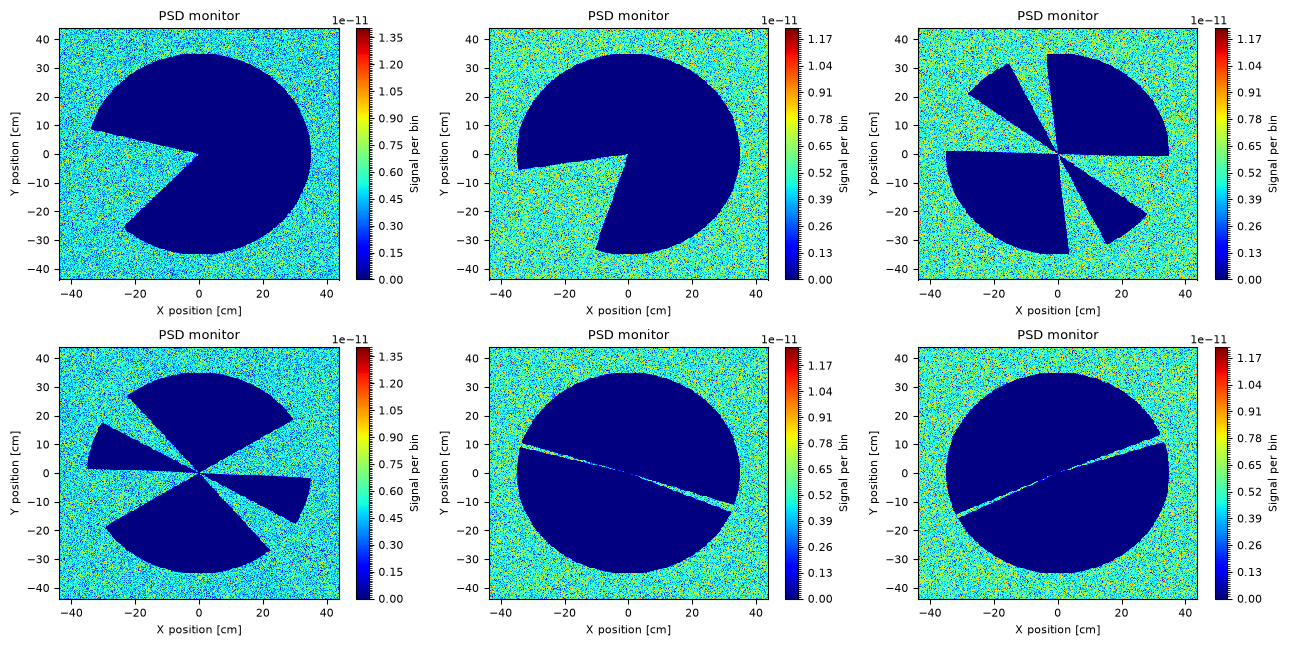

In [64]:
ms.make_sub_plot(
    data_BW1 + data_BW2 + data_P1 + data_P2 + data_M1 + data_M2,
    fontsize=8,
    aspects="equal",
)